<a href="https://colab.research.google.com/github/kessanchit2-cmd/Ml-Pracs/blob/main/Logistisc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#logistic
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [4]:
#load the dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target



In [6]:
#only use 2 species(setosa(0), versicolour(1))
mask=y<2
X=X[mask]
y=y[mask]
print(X.shape)
print(y.shape)


(100, 4)
(100,)


In [9]:
#split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
#train
model=LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [12]:
#prediction
y_pred=model.predict(X_test)
print(y_pred)

[1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]


In [16]:
#performance metrics
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred,target_names=['setosa','versicolour']))
print(confusion_matrix(y_test, y_pred))

1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
 versicolour       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

[[12  0]
 [ 0  8]]


In [17]:
#PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
print(X_pca.shape)

(100, 2)


In [18]:
#train model for visulization
vis_model=LogisticRegression()
vis_model.fit(X_pca,y)

LogisticRegression()

In [19]:
# Create mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = vis_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)




Text(0.5, 1.0, 'Logistic Regression on Iris Dataset (2 Species)')

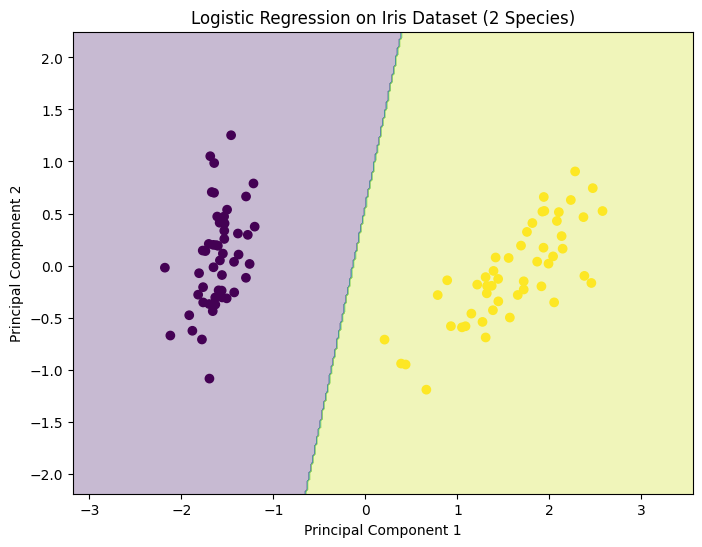

In [20]:
# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Logistic Regression on Iris Dataset (2 Species)")
